In [1]:
!pip install -q datasets transformers tokenizers
print("Done")

Done


In [2]:
import math, time, os, json
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import GPT2TokenizerFast
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [3]:
CFG = {
    # Data
    "seq_len"       : 256,
    "batch_size"    : 8,
    "num_workers"   : 2,
    # Architecture
    "vocab_size"    : 50257,
    "d_model"       : 256,
    "n_heads"       : 8,
    "n_layers"      : 4,
    "d_ff"          : 1024,
    "dropout"       : 0.1,
    # Training (shorter than Phase 1 — we compare, not fully train)
    "epochs"        : 5,
    "lr"            : 3e-4,
    "warmup_steps"  : 500,
    "grad_clip"     : 1.0,
    "weight_decay"  : 0.01,
    # Logging
    "log_every"     : 200,
    "eval_every"    : 500,
    "save_dir"      : "./checkpoints_p2",
    # Variant-specific
    "local_window"  : 64,   # Local Attention window size (tokens)
    "performer_r"   : 64,   # Performer: number of random features
    "gqa_groups"    : 2,    # GQA: number of K,V groups  (n_heads must divide)
}
print("Config loaded.")
print(f"  local_window  = {CFG['local_window']}  (attend to ±{CFG['local_window']//2} tokens)")
print(f"  performer_r   = {CFG['performer_r']}   (random feature dim)")
print(f"  gqa_groups    = {CFG['gqa_groups']}    ({CFG['n_heads']//CFG['gqa_groups']} queries share each K,V head)")

Config loaded.
  local_window  = 64  (attend to ±32 tokens)
  performer_r   = 64   (random feature dim)
  gqa_groups    = 2    (4 queries share each K,V head)


In [4]:
print("Loading WikiText-2...")

try:
    raw = load_dataset(
        "Salesforce/wikitext",
        "wikitext-2-raw-v1"
    )
except:
    raw = load_dataset(
        "wikitext",
        "wikitext-2-raw-v1"
    )

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

class WikiTextDataset(Dataset):
    def __init__(self, hf_split, tokenizer, seq_len):
        self.seq_len = seq_len
        texts = [s["text"] for s in hf_split if s["text"].strip()]
        full  = f" {tokenizer.eos_token} ".join(texts)
        ids   = tokenizer(full, return_tensors="pt",
                          truncation=False, add_special_tokens=False)["input_ids"].squeeze(0)
        n = (len(ids) - 1) // seq_len
        self.data = ids[: n * seq_len + 1]

    def __len__(self):
        return (len(self.data) - 1) // self.seq_len

    def __getitem__(self, i):
        s = i * self.seq_len
        return self.data[s:s+self.seq_len], self.data[s+1:s+self.seq_len+1]

kw = dict(num_workers=CFG["num_workers"], pin_memory=True)
train_ds     = WikiTextDataset(raw["train"],      tokenizer, CFG["seq_len"])
valid_ds     = WikiTextDataset(raw["validation"], tokenizer, CFG["seq_len"])
train_loader = DataLoader(train_ds, CFG["batch_size"],   shuffle=True,  **kw)
valid_loader = DataLoader(valid_ds, CFG["batch_size"]*2, shuffle=False, **kw)
print(f"Train batches: {len(train_loader):,}  Valid: {len(valid_loader):,}")

Loading WikiText-2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2463182 > 1024). Running this sequence through the model will result in indexing errors


Train batches: 1,203  Valid: 63


In [5]:
class AttentionModule(nn.Module):
    """
    Abstract base class for all attention variants.

    Subclasses must implement forward(x) -> (output, weights).

    Args:
        d_model : total embedding dimension
        n_heads : number of query heads
        dropout : dropout probability on attention weights / residual
    """

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError(f"d_model ({d_model}) must be divisible by n_heads ({n_heads})")
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads

    def forward(self, x: torch.Tensor):
        """
        Args:
            x : (B, T, D)
        Returns:
            output  : (B, T, D)
            weights : attention weights tensor or None
        """
        raise NotImplementedError("Subclass must implement forward()")

    def extra_repr(self):
        return f"d_model={self.d_model}, n_heads={self.n_heads}, d_head={self.d_head}"

print("AttentionModule base class defined.")

AttentionModule base class defined.


In [6]:
class StandardAttention(AttentionModule):
    """
    Standard scaled dot-product multi-head self-attention (Phase 1 baseline).

    Attention(Q,K,V) = softmax( QK^T / sqrt(d_head) ) V

    Complexity: O(T^2 * D) time, O(T^2) memory.
    """

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__(d_model, n_heads, dropout)
        self.qkv        = nn.Linear(d_model, 3*d_model, bias=False)
        self.out_proj   = nn.Linear(d_model, d_model,   bias=False)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        self.scale      = self.d_head ** -0.5

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(self.d_model, dim=-1)
        rsh = lambda t: t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = rsh(q), rsh(k), rsh(v)
        scores = torch.matmul(q, k.transpose(-2,-1)) * self.scale
        mask   = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))
        w      = self.attn_drop(F.softmax(scores, dim=-1))
        out    = torch.matmul(w, v).transpose(1,2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out)), w


# Quick test
_x = torch.randn(2, 16, 256)
_attn = StandardAttention(256, 8)
_out, _w = _attn(_x)
print(f"StandardAttention  in: {_x.shape}  →  out: {_out.shape}  weights: {_w.shape}")

StandardAttention  in: torch.Size([2, 16, 256])  →  out: torch.Size([2, 16, 256])  weights: torch.Size([2, 8, 16, 16])


LocalAttention     in: torch.Size([2, 16, 256])  →  out: torch.Size([2, 16, 256])  weights: torch.Size([2, 8, 16, 16])


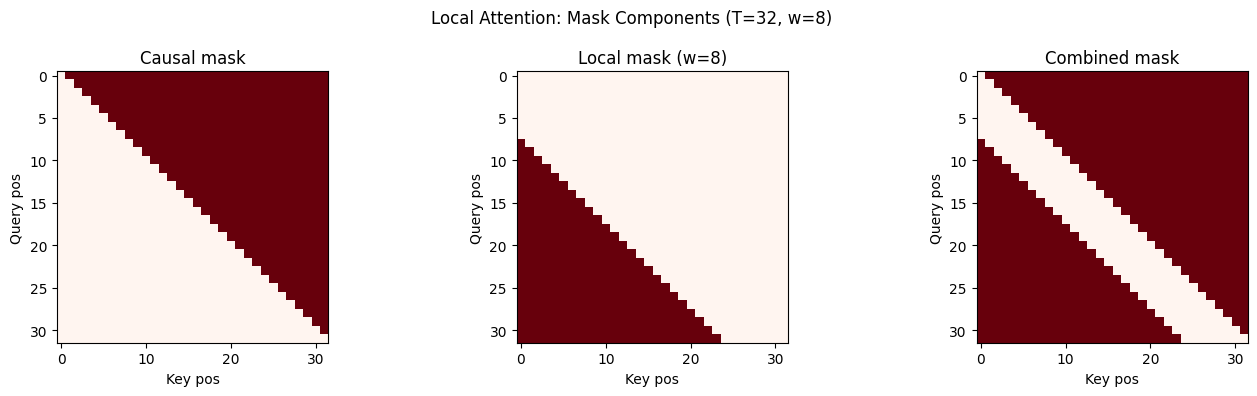

Mask visualisation saved → local_attn_mask.png


In [7]:
class LocalAttention(AttentionModule):
    """
    Sliding-window (local) attention.

    Each position i attends only to positions in [i - window_size + 1, i],
    enforcing both causality and locality.

    For a window of size w, the effective attention span is w tokens.
    Long-range dependencies beyond w tokens are lost.

    Args:
        window_size : number of past tokens each position can see (including itself)
    """

    def __init__(self, d_model, n_heads, window_size=64, dropout=0.1):
        super().__init__(d_model, n_heads, dropout)
        self.window_size = window_size
        self.qkv         = nn.Linear(d_model, 3*d_model, bias=False)
        self.out_proj    = nn.Linear(d_model, d_model,   bias=False)
        self.attn_drop   = nn.Dropout(dropout)
        self.resid_drop  = nn.Dropout(dropout)
        self.scale       = self.d_head ** -0.5

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(self.d_model, dim=-1)
        rsh = lambda t: t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = rsh(q), rsh(k), rsh(v)

        # ── Compute full attention scores (same as standard) ───────────────────
        scores = torch.matmul(q, k.transpose(-2,-1)) * self.scale  # (B, H, T, T)

        # ── Build combined causal + local mask ────────────────────────────────
        # Start with the causal mask (upper triangle = True = masked)
        causal = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)

        # Build local mask: positions more than window_size steps in the past
        # are also masked. Position i cannot see j < i - window_size + 1.
        # Equivalently: mask where i - j >= window_size  (too far in the past)
        rows  = torch.arange(T, device=x.device).unsqueeze(1)   # (T, 1)
        cols  = torch.arange(T, device=x.device).unsqueeze(0)   # (1, T)
        # True where j is too far left (more than window_size tokens ago)
        local = (rows - cols) >= self.window_size                # (T, T)

        # Combined mask: mask if future (causal) OR too far past (local)
        combined_mask = causal | local                           # (T, T)
        scores = scores.masked_fill(combined_mask, float("-inf"))

        w   = self.attn_drop(F.softmax(scores, dim=-1))
        out = torch.matmul(w, v).transpose(1,2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out)), w


# Test
_attn = LocalAttention(256, 8, window_size=64)
_out, _w = _attn(_x)
print(f"LocalAttention     in: {_x.shape}  →  out: {_out.shape}  weights: {_w.shape}")

# Visualise the mask pattern
_T = 32
_rows = torch.arange(_T).unsqueeze(1); _cols = torch.arange(_T).unsqueeze(0)
_causal = torch.triu(torch.ones(_T,_T,dtype=torch.bool),diagonal=1)
_local  = (_rows - _cols) >= 8
_mask   = _causal | _local
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, m, title in zip(axes,
    [_causal, _local, _mask],
    ["Causal mask", "Local mask (w=8)", "Combined mask"]):
    ax.imshow(m.numpy(), cmap="Reds", vmin=0, vmax=1)
    ax.set_title(title); ax.set_xlabel("Key pos"); ax.set_ylabel("Query pos")
plt.suptitle("Local Attention: Mask Components (T=32, w=8)", fontsize=12)
plt.tight_layout(); plt.savefig("local_attn_mask.png", dpi=120); plt.show()
print("Mask visualisation saved → local_attn_mask.png")

In [8]:
class PerformerAttention(AttentionModule):
    """
    Performer attention using FAVOR+ (Fast Attention Via positive Orthogonal
    Random features).

    Approximates softmax attention in O(T * r * d) instead of O(T^2 * d),
    where r is the number of random features (much smaller than T).

    For causal (autoregressive) models, uses the prefix-sum trick to ensure
    position i only attends to positions j <= i.

    Reference: Choromanski et al., 2020 — "Rethinking Attention with Performers"

    Args:
        num_features : r, number of random projection features (default 64)
                       Higher r → better approximation, more memory
    """

    def __init__(self, d_model, n_heads, num_features=64, dropout=0.1):
        super().__init__(d_model, n_heads, dropout)
        self.num_features = num_features

        self.qkv        = nn.Linear(d_model, 3*d_model, bias=False)
        self.out_proj   = nn.Linear(d_model, d_model,   bias=False)
        self.resid_drop = nn.Dropout(dropout)

        # Random projection matrix ω ∈ R^{r × d_head}
        # We register this as a buffer: it moves to GPU with the model
        # but is NOT a learnable parameter.
        # Using orthogonal random features (ORF) — better variance than iid.
        self._init_random_features()

    def _init_random_features(self):
        """
        Initialise orthogonal random features.
        For d_head features per block, we create ceil(r / d_head) orthogonal blocks.
        """
        d = self.d_head
        r = self.num_features

        # Create random Gaussian matrices and orthogonalise via QR decomposition
        blocks = []
        n_blocks = math.ceil(r / d)
        for _ in range(n_blocks):
            g  = torch.randn(d, d)
            q, _ = torch.linalg.qr(g)           # orthonormal columns
            # Scale rows by chi-distributed values (matches Gaussian norms)
            s = torch.diag(torch.sqrt(torch.tensor([
                float(torch.distributions.Chi2(df=torch.tensor(float(d))).sample())
                for _ in range(d)
            ])))
            blocks.append(s @ q)

        omega = torch.cat(blocks, dim=0)[:r]     # (r, d_head)
        self.register_buffer("omega", omega)     # moves to GPU automatically

    def _feature_map(self, x: torch.Tensor) -> torch.Tensor:
        """
        FAVOR+ positive feature map.

        φ(x) = exp(ω x^T - ||x||^2/2) / sqrt(r)

        This guarantees φ(q)φ(k)^T ≥ 0 and approximates exp(q·k).

        Args:
            x : (B, H, T, d_head)
        Returns:
            (B, H, T, r)  — feature-mapped representation
        """
        # omega: (r, d_head)
        # x:     (B, H, T, d_head)
        # proj = x @ omega^T → (B, H, T, r)
        proj = torch.einsum("bhte,re->bhtr", x, self.omega)

        # ||x||^2 / 2, shape (B, H, T, 1) for broadcasting
        norm2 = (x * x).sum(dim=-1, keepdim=True) * 0.5

        # exp(proj - norm2): positive, approximates exp(q·k)
        # Add small eps for numerical stability
        features = torch.exp(proj - norm2) / math.sqrt(self.num_features)
        return features   # (B, H, T, r)

    def forward(self, x):
        """
        Causal Performer attention using prefix sums.

        For each position i:
            S_i = sum_{j<=i} phi(k_j) ⊗ v_j     (r x d_head outer product sum)
            out_i = phi(q_i) S_i                  (query the running sum)
        """
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(self.d_model, dim=-1)
        rsh = lambda t: t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = rsh(q), rsh(k), rsh(v)         # each (B, H, T, d_head)

        # Map Q and K through the random feature map
        q_prime = self._feature_map(q)            # (B, H, T, r)
        k_prime = self._feature_map(k)            # (B, H, T, r)

        # ── Causal prefix-sum attention ───────────────────────────────────────
        # S[i] = sum_{j=0}^{i} k_prime[j]^T ⊗ v[j]  — shape: (B, H, r, d_head)
        # out[i] = q_prime[i] @ S[i]                 — shape: (B, H, d_head)
        #
        # We compute this step by step (O(T) passes, each O(r*d_head)):

        outputs  = []
        S        = torch.zeros(B, self.n_heads, self.num_features, self.d_head,
                               device=x.device, dtype=x.dtype)   # running KV sum
        Z        = torch.zeros(B, self.n_heads, self.num_features,
                               device=x.device, dtype=x.dtype)   # normaliser

        for t in range(T):
            # k_prime at position t: (B, H, r)
            kt = k_prime[:, :, t, :]              # (B, H, r)
            vt = v[:, :, t, :]                    # (B, H, d_head)

            # Update running sum: S += kt^T ⊗ vt
            # einsum: (B,H,r) × (B,H,d) → (B,H,r,d)
            S = S + torch.einsum("bhr,bhd->bhrd", kt, vt)
            Z = Z + kt                             # normaliser (B, H, r)

            # Query: qt @ S[t]
            qt  = q_prime[:, :, t, :]             # (B, H, r)
            out_t = torch.einsum("bhr,bhrd->bhd", qt, S)   # (B, H, d_head)

            # Normalise (denominator of softmax approximation)
            z_t = torch.einsum("bhr,bhr->bh", qt, Z).unsqueeze(-1) + 1e-6
            out_t = out_t / z_t                   # (B, H, d_head)
            outputs.append(out_t)

        # Stack: (T, B, H, d_head) → (B, T, H, d_head) → (B, T, C)
        out = torch.stack(outputs, dim=2)          # (B, H, T, d_head)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out)), None   # no full weight matrix to return


# Test
_attn = PerformerAttention(256, 8, num_features=64)
_out, _w = _attn(_x)
print(f"PerformerAttention in: {_x.shape}  →  out: {_out.shape}  weights: {_w}")
print("(weights=None because we never form the T×T matrix — that's the point!)")

PerformerAttention in: torch.Size([2, 16, 256])  →  out: torch.Size([2, 16, 256])  weights: None
(weights=None because we never form the T×T matrix — that's the point!)


In [9]:
class GroupedQueryAttention(AttentionModule):
    """
    Grouped Query Attention (GQA).

    n_heads query heads are split into n_kv_heads groups.
    Each group of (n_heads // n_kv_heads) query heads shares one K,V head.

    Args:
        n_kv_heads : number of K,V heads (must divide n_heads evenly)
                     n_kv_heads = n_heads → standard MHA
                     n_kv_heads = 1       → multi-query attention

    Reference: Ainslie et al., 2023 — "GQA: Training Generalized Multi-Query
               Transformer Models from Multi-Head Checkpoints"
    """

    def __init__(self, d_model, n_heads, n_kv_heads=2, dropout=0.1):
        super().__init__(d_model, n_heads, dropout)
        if n_heads % n_kv_heads != 0:
            raise ValueError(f"n_heads ({n_heads}) must be divisible by n_kv_heads ({n_kv_heads})")

        self.n_kv_heads   = n_kv_heads
        self.n_rep        = n_heads // n_kv_heads   # how many Q heads share each K,V

        # Query projection: still n_heads * d_head = d_model dims
        self.q_proj  = nn.Linear(d_model, d_model,               bias=False)
        # K,V projections: only n_kv_heads * d_head dims (SMALLER than standard)
        self.k_proj  = nn.Linear(d_model, n_kv_heads * self.d_head, bias=False)
        self.v_proj  = nn.Linear(d_model, n_kv_heads * self.d_head, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        self.scale      = self.d_head ** -0.5

    def _repeat_kv(self, x: torch.Tensor) -> torch.Tensor:
        """
        Expand K or V from (B, n_kv_heads, T, d_head) to
        (B, n_heads, T, d_head) by repeating each head n_rep times.

        This is an efficient view-based repeat (no data copy).
        """
        B, H, T, D = x.shape
        if self.n_rep == 1:
            return x   # already full size (standard MHA case)
        # Insert a new dim, expand, then reshape
        return (
            x[:, :, None, :, :]                        # (B, H, 1, T, D)
            .expand(B, H, self.n_rep, T, D)            # (B, H, n_rep, T, D)
            .reshape(B, H * self.n_rep, T, D)          # (B, n_heads, T, D)
        )

    def forward(self, x):
        B, T, C = x.shape

        # Query: (B, T, d_model) → (B, n_heads, T, d_head)
        q = self.q_proj(x).view(B, T, self.n_heads,   self.d_head).transpose(1, 2)
        # Key, Value: (B, T, n_kv_heads*d_head) → (B, n_kv_heads, T, d_head)
        k = self.k_proj(x).view(B, T, self.n_kv_heads, self.d_head).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_kv_heads, self.d_head).transpose(1, 2)

        # Broadcast K,V: repeat each K,V head n_rep times → (B, n_heads, T, d_head)
        k = self._repeat_kv(k)
        v = self._repeat_kv(v)

        # Standard scaled dot-product attention from here
        scores = torch.matmul(q, k.transpose(-2,-1)) * self.scale
        mask   = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))
        w      = self.attn_drop(F.softmax(scores, dim=-1))
        out    = torch.matmul(w, v).transpose(1,2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out)), w


# Test
_attn = GroupedQueryAttention(256, 8, n_kv_heads=2)
_out, _w = _attn(_x)
print(f"GroupedQueryAttn   in: {_x.shape}  →  out: {_out.shape}  weights: {_w.shape}")

# Parameter count comparison
def count_attn_params(attn):
    return sum(p.numel() for p in attn.parameters())

print("\nParameter count comparison (d_model=256, n_heads=8):")
print(f"  StandardAttention   : {count_attn_params(StandardAttention(256,8)):,}")
print(f"  LocalAttention      : {count_attn_params(LocalAttention(256,8)):,}")
print(f"  PerformerAttention  : {count_attn_params(PerformerAttention(256,8)):,}")
print(f"  GQA (G=2)           : {count_attn_params(GroupedQueryAttention(256,8,2)):,}")
print(f"  GQA (G=1, MQA)      : {count_attn_params(GroupedQueryAttention(256,8,1)):,}")

GroupedQueryAttn   in: torch.Size([2, 16, 256])  →  out: torch.Size([2, 16, 256])  weights: torch.Size([2, 8, 16, 16])

Parameter count comparison (d_model=256, n_heads=8):
  StandardAttention   : 262,144
  LocalAttention      : 262,144
  PerformerAttention  : 262,144
  GQA (G=2)           : 163,840
  GQA (G=1, MQA)      : 147,456


In [10]:
# ── Shared components (unchanged from Phase 1) ──────────────────────────────

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)


class TransformerBlock(nn.Module):
    """Pre-LN Transformer block. attention_module is any AttentionModule subclass."""
    def __init__(self, attention_module, d_model, d_ff, dropout):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = attention_module          # ← pluggable
        self.ln2  = nn.LayerNorm(d_model)
        self.ff   = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        a, w = self.attn(self.ln1(x));  x = x + a
        x    = x + self.ff(self.ln2(x))
        return x, w


class DecoderOnlyTransformer(nn.Module):
    def __init__(self, cfg, attention_modules):
        """
        Args:
            attention_modules : list of AttentionModule instances, len = n_layers
        """
        super().__init__()
        D, V, T = cfg["d_model"], cfg["vocab_size"], cfg["seq_len"]
        self.tok_emb = nn.Embedding(V, D)
        self.pos_emb = nn.Embedding(T, D)
        self.drop    = nn.Dropout(cfg["dropout"])
        self.blocks  = nn.ModuleList([
            TransformerBlock(attn, D, cfg["d_ff"], cfg["dropout"])
            for attn in attention_modules
        ])
        self.ln_f    = nn.LayerNorm(D)
        self.lm_head = nn.Linear(D, V, bias=False)
        self.lm_head.weight = self.tok_emb.weight
        self.apply(self._init_weights)
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Parameters: {n:,}  ({n/1e6:.2f}M)")

    def _init_weights(self, m):
        if isinstance(m, nn.Linear): nn.init.normal_(m.weight, 0, 0.02)
        elif isinstance(m, nn.Embedding): nn.init.normal_(m.weight, 0, 0.02)
        elif isinstance(m, nn.LayerNorm): nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, idx):
        B, T = idx.shape
        x = self.drop(self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device)))
        attn_list = []
        for blk in self.blocks:
            x, w = blk(x); attn_list.append(w)
        return self.ln_f(x) @ self.lm_head.weight.T, attn_list


# ── Factory function ──────────────────────────────────────────────────────────
ATTENTION_REGISTRY = {
    "standard" : lambda cfg: StandardAttention(
        cfg["d_model"], cfg["n_heads"], cfg["dropout"]),
    "local"    : lambda cfg: LocalAttention(
        cfg["d_model"], cfg["n_heads"], cfg["local_window"], cfg["dropout"]),
    "performer": lambda cfg: PerformerAttention(
        cfg["d_model"], cfg["n_heads"], cfg["performer_r"], cfg["dropout"]),
    "gqa"      : lambda cfg: GroupedQueryAttention(
        cfg["d_model"], cfg["n_heads"], cfg["gqa_groups"], cfg["dropout"]),
}

def build_lm(cfg: dict, attention: str) -> DecoderOnlyTransformer:
    """
    Build a language model with the specified attention variant.

    Args:
        cfg       : hyperparameter dict
        attention : one of "standard", "local", "performer", "gqa"
    """
    if attention not in ATTENTION_REGISTRY:
        raise ValueError(f"Unknown attention: {attention}. Choose from {list(ATTENTION_REGISTRY)}")
    print(f"\nBuilding model with attention='{attention}' …")
    modules = [ATTENTION_REGISTRY[attention](cfg) for _ in range(cfg["n_layers"])]
    return DecoderOnlyTransformer(cfg, modules).to(DEVICE)


# Quick build test — all variants
for name in ATTENTION_REGISTRY:
    m = build_lm(CFG, name)
    _x = torch.randint(0, CFG["vocab_size"], (1, 32), device=DEVICE)
    _out, _ = m(_x)
    print(f"  ✔  {name:12s}  output: {_out.shape}")
    del m, _x, _out


Building model with attention='standard' …
  Parameters: 16,086,784  (16.09M)
  ✔  standard      output: torch.Size([1, 32, 50257])

Building model with attention='local' …
  Parameters: 16,086,784  (16.09M)
  ✔  local         output: torch.Size([1, 32, 50257])

Building model with attention='performer' …
  Parameters: 16,086,784  (16.09M)
  ✔  performer     output: torch.Size([1, 32, 50257])

Building model with attention='gqa' …
  Parameters: 15,693,568  (15.69M)
  ✔  gqa           output: torch.Size([1, 32, 50257])


In [11]:
def compute_loss(logits, targets):
    B, T, V = logits.shape
    return F.cross_entropy(
    logits.reshape(B*T,V),
    targets.reshape(B*T)
)

def get_lr(step, total_steps, cfg):
    w, hi, lo = cfg["warmup_steps"], cfg["lr"], cfg["lr"]*0.1
    if step < w: return hi*(step+1)/w
    prog = min((step-w)/max(1,total_steps-w),1.0)
    return lo+0.5*(hi-lo)*(1+math.cos(math.pi*prog))

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); tot=n=0
    for x,y in loader:
        x,y=x.to(DEVICE),y.to(DEVICE)
        logits,_=model(x); tot+=compute_loss(logits,y).item(); n+=1
    model.train(); avg=tot/n
    return {"loss":avg, "ppl":math.exp(avg)}

def make_optimiser(model, cfg):
    decay, no_decay = [], []
    for name,p in model.named_parameters():
        if not p.requires_grad: continue
        (no_decay if p.dim()==1 or any(k in name for k in ("ln","bias","emb")) else decay).append(p)
    return torch.optim.AdamW(
        [{"params":decay,"weight_decay":cfg["weight_decay"]},
         {"params":no_decay,"weight_decay":0.0}],
        lr=cfg["lr"], betas=(0.9,0.95), eps=1e-8)

def train_variant(model, cfg, variant_name, save_dir="./checkpoints_p2"):
    """Train a model variant and return its history dict."""
    os.makedirs(save_dir, exist_ok=True)
    opt = make_optimiser(model, cfg)
    total = cfg["epochs"] * len(train_loader)
    step  = 0; model.train()
    history = {"tl":[],"ts":[],"vl":[],"vp":[],"vs":[]}

    print(f"\n{'='*55}")
    print(f"  Training: {variant_name}  ({cfg['epochs']} epochs)")
    print(f"{'='*55}")

    for ep in range(cfg["epochs"]):
        for x,y in train_loader:
            x,y=x.to(DEVICE),y.to(DEVICE)
            for pg in opt.param_groups: pg["lr"]=get_lr(step,total,cfg)
            logits,_=model(x); loss=compute_loss(logits,y)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),cfg["grad_clip"])
            opt.step()
            lv=loss.item(); history["tl"].append(lv); history["ts"].append(step)
            if step % cfg["log_every"]==0:
                print(f"  [{variant_name}] Ep{ep+1} Step{step:5d} "
                      f"Loss{lv:.4f} PPL{math.exp(lv):.1f} "
                      f"LR{get_lr(step,total,cfg):.2e}")
            if step % cfg["eval_every"]==0 and step>0:
                vm=evaluate(model,valid_loader)
                history["vl"].append(vm["loss"]); history["vp"].append(vm["ppl"])
                history["vs"].append(step)
                print(f"  [{variant_name}] VALID  Loss{vm['loss']:.4f}  PPL{vm['ppl']:.2f}")
            step+=1
        ep_avg=sum(history["tl"][-len(train_loader):])/len(train_loader)
        print(f"  [{variant_name}] Epoch {ep+1} done | AvgPPL {math.exp(ep_avg):.2f}")

    # Final validation
    final=evaluate(model,valid_loader)
    history["final_ppl"]=final["ppl"]
    history["final_loss"]=final["loss"]
    print(f"\n  [{variant_name}] FINAL  Loss{final['loss']:.4f}  PPL{final['ppl']:.2f}")
    torch.save({"model":model.state_dict(),"history":history,"cfg":cfg},
               f"{save_dir}/{variant_name}_final.pt")
    return history

print("Training utilities defined.")

Training utilities defined.


In [12]:
def benchmark_variant(model, n_batches=30):
    """
    Measure training throughput (tokens/sec) and peak GPU memory (MB).

    Returns dict with keys: throughput_tps, peak_mem_mb
    """
    model.train()
    _opt = torch.optim.SGD(model.parameters(), lr=1e-4)

    # Reset memory stats
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    # Warm-up (1 batch to load CUDA kernels)
    x0, y0 = next(iter(train_loader))
    x0, y0 = x0.to(DEVICE), y0.to(DEVICE)
    compute_loss(model(x0)[0], y0).backward(); _opt.zero_grad()

    if DEVICE.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter(); total_tokens = 0

    for i, (x,y) in enumerate(train_loader):
        if i >= n_batches: break
        x,y=x.to(DEVICE),y.to(DEVICE)
        compute_loss(model(x)[0],y).backward(); _opt.zero_grad()
        total_tokens += x.numel()

    if DEVICE.type == "cuda": torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    tps = total_tokens / elapsed

    peak_mem = 0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated() / 1e6  # MB

    return {"throughput_tps": tps, "peak_mem_mb": peak_mem}


# ── Run benchmarks for all variants ──────────────────────────────────────────
print("Running benchmarks (this takes ~2-3 min) …\n")
bench_results = {}

for variant_name in ATTENTION_REGISTRY:
    print(f"  Benchmarking: {variant_name} …", end=" ", flush=True)
    m = build_lm(CFG, variant_name)
    r = benchmark_variant(m, n_batches=30)
    bench_results[variant_name] = r
    print(f"{r['throughput_tps']:,.0f} t/s  |  {r['peak_mem_mb']:.0f} MB")
    del m
    if DEVICE.type == "cuda": torch.cuda.empty_cache()

print("\nBenchmark results:")
print(f"  {'Variant':<16}  {'Throughput (t/s)':>18}  {'Peak GPU Mem (MB)':>18}")
print(f"  {'-'*16}  {'-'*18}  {'-'*18}")
for k,v in bench_results.items():
    print(f"  {k:<16}  {v['throughput_tps']:>18,.0f}  {v['peak_mem_mb']:>18.1f}")

Running benchmarks (this takes ~2-3 min) …

  Benchmarking: standard … 
Building model with attention='standard' …
  Parameters: 16,086,784  (16.09M)
25,132 t/s  |  1685 MB
  Benchmarking: local … 
Building model with attention='local' …
  Parameters: 16,086,784  (16.09M)
26,141 t/s  |  1684 MB
  Benchmarking: performer … 
Building model with attention='performer' …
  Parameters: 16,086,784  (16.09M)
1,720 t/s  |  2162 MB
  Benchmarking: gqa … 
Building model with attention='gqa' …
  Parameters: 15,693,568  (15.69M)
25,638 t/s  |  1682 MB

Benchmark results:
  Variant             Throughput (t/s)   Peak GPU Mem (MB)
  ----------------  ------------------  ------------------
  standard                      25,132              1685.0
  local                         26,141              1684.0
  performer                      1,720              2162.5
  gqa                           25,638              1682.4


In [13]:
# ── Train each variant and collect results ────────────────────────────────────
all_histories = {}
all_models    = {}   # keep final models for inspection

for variant_name in ATTENTION_REGISTRY:
    # Build fresh model
    model = build_lm(CFG, variant_name)

    # Train
    hist = train_variant(model, CFG, variant_name)
    all_histories[variant_name] = hist

    # Keep a reference for later inspection
    all_models[variant_name] = model

    # Free GPU memory before next variant
    # (comment out if you want all models loaded simultaneously)
    # del model; torch.cuda.empty_cache()

print("\n\nAll variants trained.")


Building model with attention='standard' …
  Parameters: 16,086,784  (16.09M)

  Training: standard  (5 epochs)
  [standard] Ep1 Step    0 Loss10.8459 PPL51324.4 LR6.00e-07
  [standard] Ep1 Step  200 Loss7.6341 PPL2067.5 LR1.21e-04
  [standard] Ep1 Step  400 Loss6.5608 PPL706.8 LR2.41e-04
  [standard] VALID  Loss6.5133  PPL674.07
  [standard] Ep1 Step  600 Loss6.3292 PPL560.7 LR3.00e-04
  [standard] Ep1 Step  800 Loss6.0808 PPL437.4 LR2.98e-04
  [standard] Ep1 Step 1000 Loss6.2276 PPL506.6 LR2.95e-04
  [standard] VALID  Loss6.1242  PPL456.80
  [standard] Ep1 Step 1200 Loss5.7444 PPL312.4 LR2.89e-04
  [standard] Epoch 1 done | AvgPPL 996.67
  [standard] Ep2 Step 1400 Loss6.0850 PPL439.2 LR2.83e-04
  [standard] VALID  Loss5.9553  PPL385.81
  [standard] Ep2 Step 1600 Loss5.8454 PPL345.6 LR2.74e-04
  [standard] Ep2 Step 1800 Loss5.8408 PPL344.0 LR2.65e-04
  [standard] Ep2 Step 2000 Loss5.6600 PPL287.2 LR2.54e-04
  [standard] VALID  Loss5.8395  PPL343.60
  [standard] Ep2 Step 2200 Loss5.78

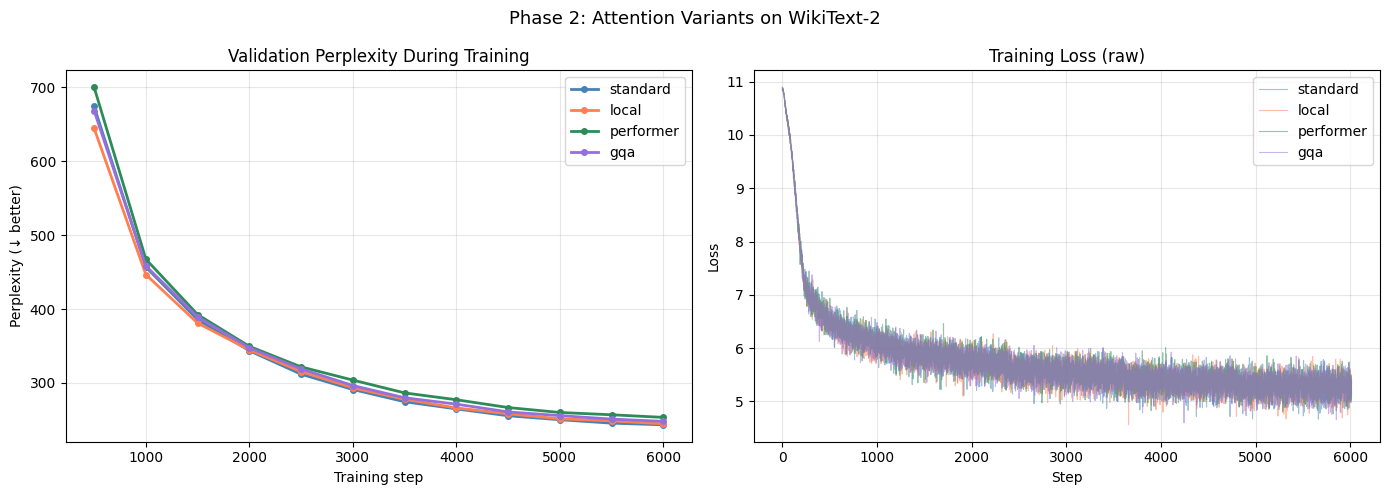

Saved → attention_ppl_curves.png


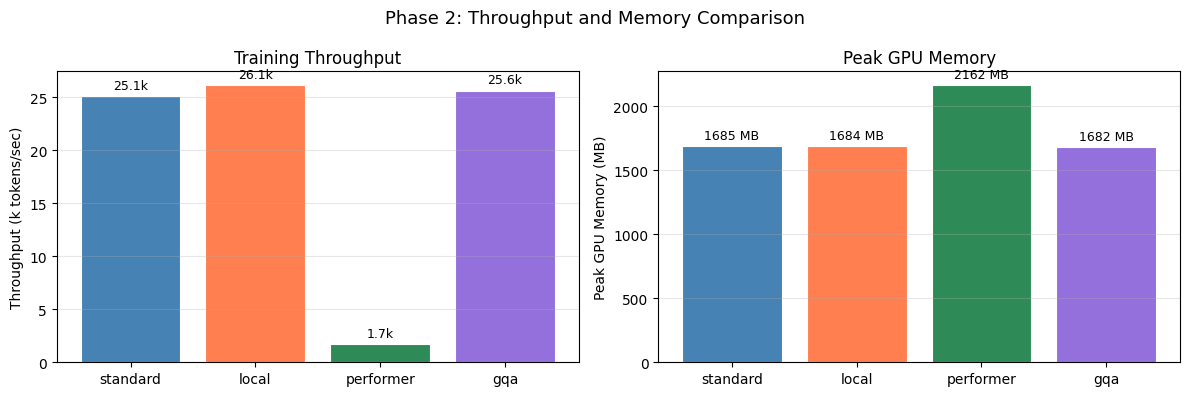

Saved → attention_throughput.png


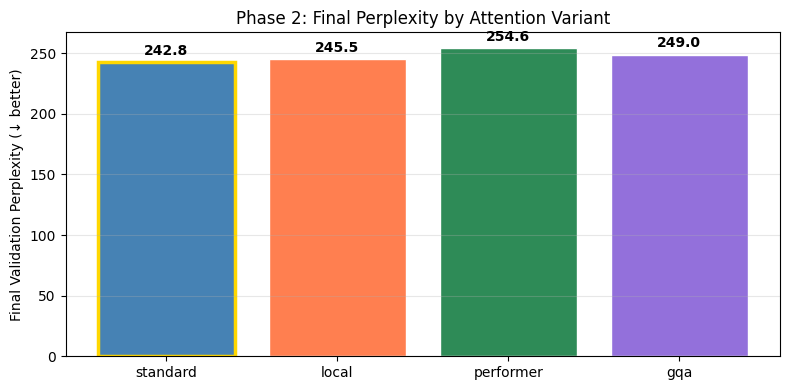

Saved → attention_final_ppl.png

PHASE 2 RESULTS SUMMARY
Variant            Final Val PPL    Throughput (t/s)    Mem (MB)
------------------------------------------------------------------------
  standard                242.77              25,132      1685.0 ← best PPL
  local                   245.49              26,141      1684.0
  performer               254.58               1,720      2162.5
  gqa                     248.96              25,638      1682.4

Saved → phase2_summary.json


In [14]:
# ── Colour scheme ────────────────────────────────────────────────────────────
COLORS = {
    "standard" : "steelblue",
    "local"    : "coral",
    "performer": "seagreen",
    "gqa"      : "mediumpurple",
}

# ── Figure 1: Validation perplexity over training steps ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, hist in all_histories.items():
    if hist["vs"]:
        ax.plot(hist["vs"], hist["vp"], "o-", color=COLORS[name],
                label=name, lw=2, ms=4)
ax.set_xlabel("Training step"); ax.set_ylabel("Perplexity (↓ better)")
ax.set_title("Validation Perplexity During Training")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for name, hist in all_histories.items():
    ax.plot(hist["ts"], hist["tl"], alpha=0.5, color=COLORS[name], lw=0.8, label=name)
ax.set_xlabel("Step"); ax.set_ylabel("Loss")
ax.set_title("Training Loss (raw)"); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Phase 2: Attention Variants on WikiText-2", fontsize=13)
plt.tight_layout(); plt.savefig("attention_ppl_curves.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved → attention_ppl_curves.png")

# ── Figure 2: Throughput and Memory bar charts ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names  = list(bench_results.keys())
tps    = [bench_results[n]["throughput_tps"]/1000 for n in names]  # in k tok/s
mem    = [bench_results[n]["peak_mem_mb"] for n in names]
colors = [COLORS[n] for n in names]

ax = axes[0]
bars = ax.bar(names, tps, color=colors, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, fmt="%.1fk", padding=3, fontsize=9)
ax.set_ylabel("Throughput (k tokens/sec)"); ax.set_title("Training Throughput")
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
bars = ax.bar(names, mem, color=colors, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, fmt="%.0f MB", padding=3, fontsize=9)
ax.set_ylabel("Peak GPU Memory (MB)"); ax.set_title("Peak GPU Memory")
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Phase 2: Throughput and Memory Comparison", fontsize=13)
plt.tight_layout(); plt.savefig("attention_throughput.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved → attention_throughput.png")

# ── Figure 3: Final PPL bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
final_ppls = [all_histories[n]["final_ppl"] for n in names]
bars = ax.bar(names, final_ppls, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=10, fontweight="bold")
ax.set_ylabel("Final Validation Perplexity (↓ better)")
ax.set_title("Phase 2: Final Perplexity by Attention Variant")
ax.grid(axis="y", alpha=0.3)
# Highlight best
best_idx = int(np.argmin(final_ppls))
bars[best_idx].set_edgecolor("gold"); bars[best_idx].set_linewidth(2.5)
plt.tight_layout(); plt.savefig("attention_final_ppl.png", dpi=150); plt.show()
print("Saved → attention_final_ppl.png")

# ── Final results table ───────────────────────────────────────────────────────
print("\n" + "="*72)
print("PHASE 2 RESULTS SUMMARY")
print("="*72)
print(f"{'Variant':<16}  {'Final Val PPL':>14}  {'Throughput (t/s)':>18}  {'Mem (MB)':>10}")
print("-"*72)
for n in names:
    ppl  = all_histories[n]["final_ppl"]
    tps_ = bench_results[n]["throughput_tps"]
    mem_ = bench_results[n]["peak_mem_mb"]
    flag = " ← best PPL" if n == names[best_idx] else ""
    print(f"  {n:<14}  {ppl:>14.2f}  {tps_:>18,.0f}  {mem_:>10.1f}{flag}")
print("="*72)

# Save summary
summary = {
    n: {"final_ppl"     : all_histories[n]["final_ppl"],
        "throughput_tps": bench_results[n]["throughput_tps"],
        "peak_mem_mb"   : bench_results[n]["peak_mem_mb"]}
    for n in names
}
with open("phase2_summary.json","w") as f: json.dump(summary,f,indent=2)
print("\nSaved → phase2_summary.json")

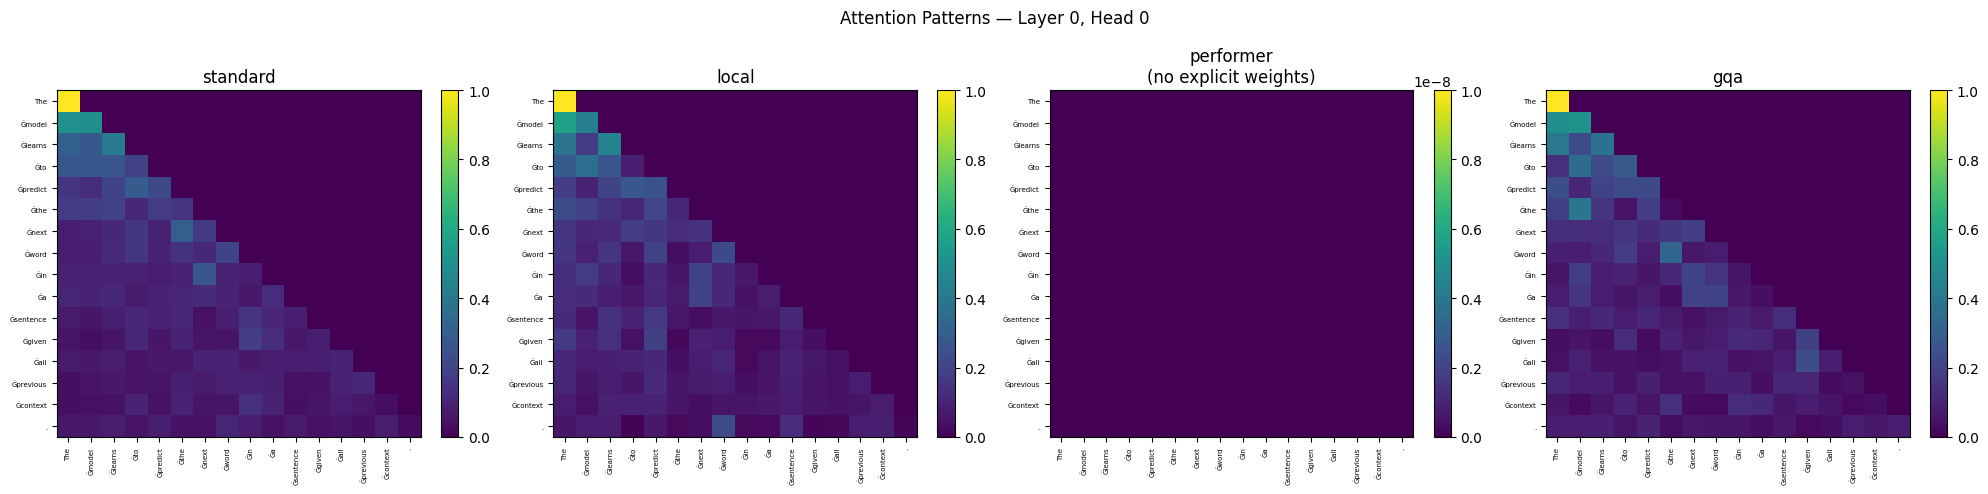

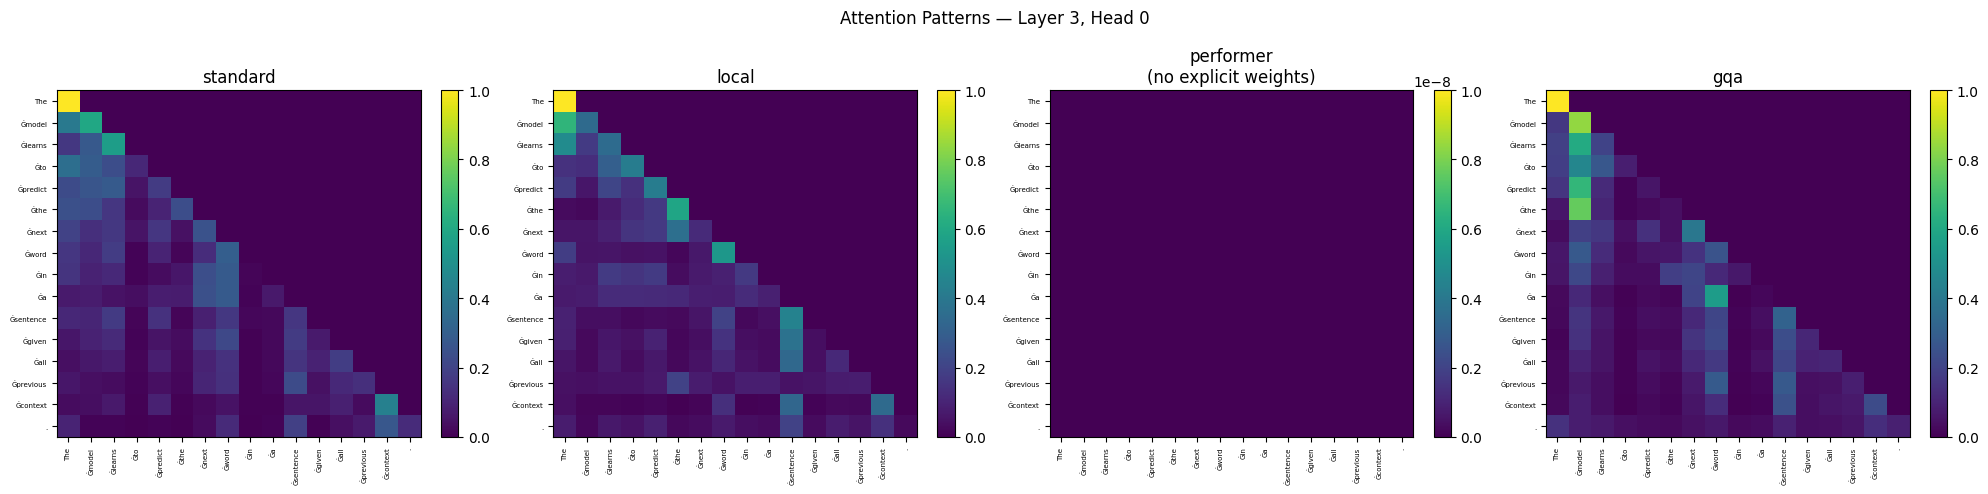

Attention comparisons saved.


In [15]:
@torch.no_grad()
def plot_attn_comparison(text, variants_dict, layer=0, head=0):
    """Plot attention heatmaps side-by-side for multiple variants."""
    ids = tokenizer(text, return_tensors="pt")["input_ids"][:, :64].to(DEVICE)
    toks = tokenizer.convert_ids_to_tokens(ids[0].tolist())
    T    = len(toks)

    n_variants = len(variants_dict)
    fig, axes  = plt.subplots(1, n_variants, figsize=(5*n_variants, 5))
    if n_variants == 1: axes = [axes]

    for ax, (name, model) in zip(axes, variants_dict.items()):
        model.eval()
        _, attn_list = model(ids)
        w = attn_list[layer]
        if w is None:
            # Performer: no explicit weight matrix → show zeros
            attn = np.zeros((T, T))
            ax.set_title(f"{name}\n(no explicit weights)")
        else:
            attn = w[0, head].cpu().numpy()[:T, :T]
            ax.set_title(f"{name}")

        im = ax.imshow(attn, cmap="viridis", aspect="auto", vmin=0, vmax=attn.max()+1e-8)
        ax.set_xticks(range(T)); ax.set_xticklabels(toks, rotation=90, fontsize=5)
        ax.set_yticks(range(T)); ax.set_yticklabels(toks, fontsize=5)
        plt.colorbar(im, ax=ax, fraction=0.046)
        model.train()

    plt.suptitle(f"Attention Patterns — Layer {layer}, Head {head}", fontsize=12)
    plt.tight_layout(); plt.savefig(f"attn_comparison_l{layer}_h{head}.png", dpi=120)
    plt.show()

TEXT = "The model learns to predict the next word in a sentence given all previous context."
plot_attn_comparison(TEXT, all_models, layer=0, head=0)
plot_attn_comparison(TEXT, all_models, layer=CFG["n_layers"]-1, head=0)
print("Attention comparisons saved.")